In [1]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [2]:
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

from utils.heatpipe_utils import generate_cfgs_seq, generate_cfg, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

import utils.sodium_properties as s_props
import data.dataclass as d_class

%config InlineBackend.figure_format = "retina"

Mesh warning: N_Z changed from 50 to 46
Mesh warning: Neutronics N_Z changed from 50 to 30
Mesh warning: N_R changed from 15 to 65


In [3]:
with open("data/vapour_data.json", "r") as f:
    exp_data = json.load(f)
    data_560 = exp_data["data_guoju_560"]

geom = d_class.HeatpipeGeometry(**data_560["geometry"])
mesh = d_class.HeatpipeMesh(N_R = 15, N_Z=80)
mat  = d_class.HeatpipeMaterial(**data_560["material"])
wick = d_class.HeatpipeWick(**data_560["wick"])
bc   = d_class.HeatpipeBC(**data_560["bc"])
cfg_560 = d_class.HeatpipeConfig(geom, mesh, mat, wick, bc)
cfg_560 = cfg_560.resolve_mesh()

Mesh warning: N_R changed from 15 to 18


In [4]:
heatpipe = Heatpipe(cfg_560)

solver = Solver([heatpipe])
solver.fsolve()

fsolve message: The solution converged.


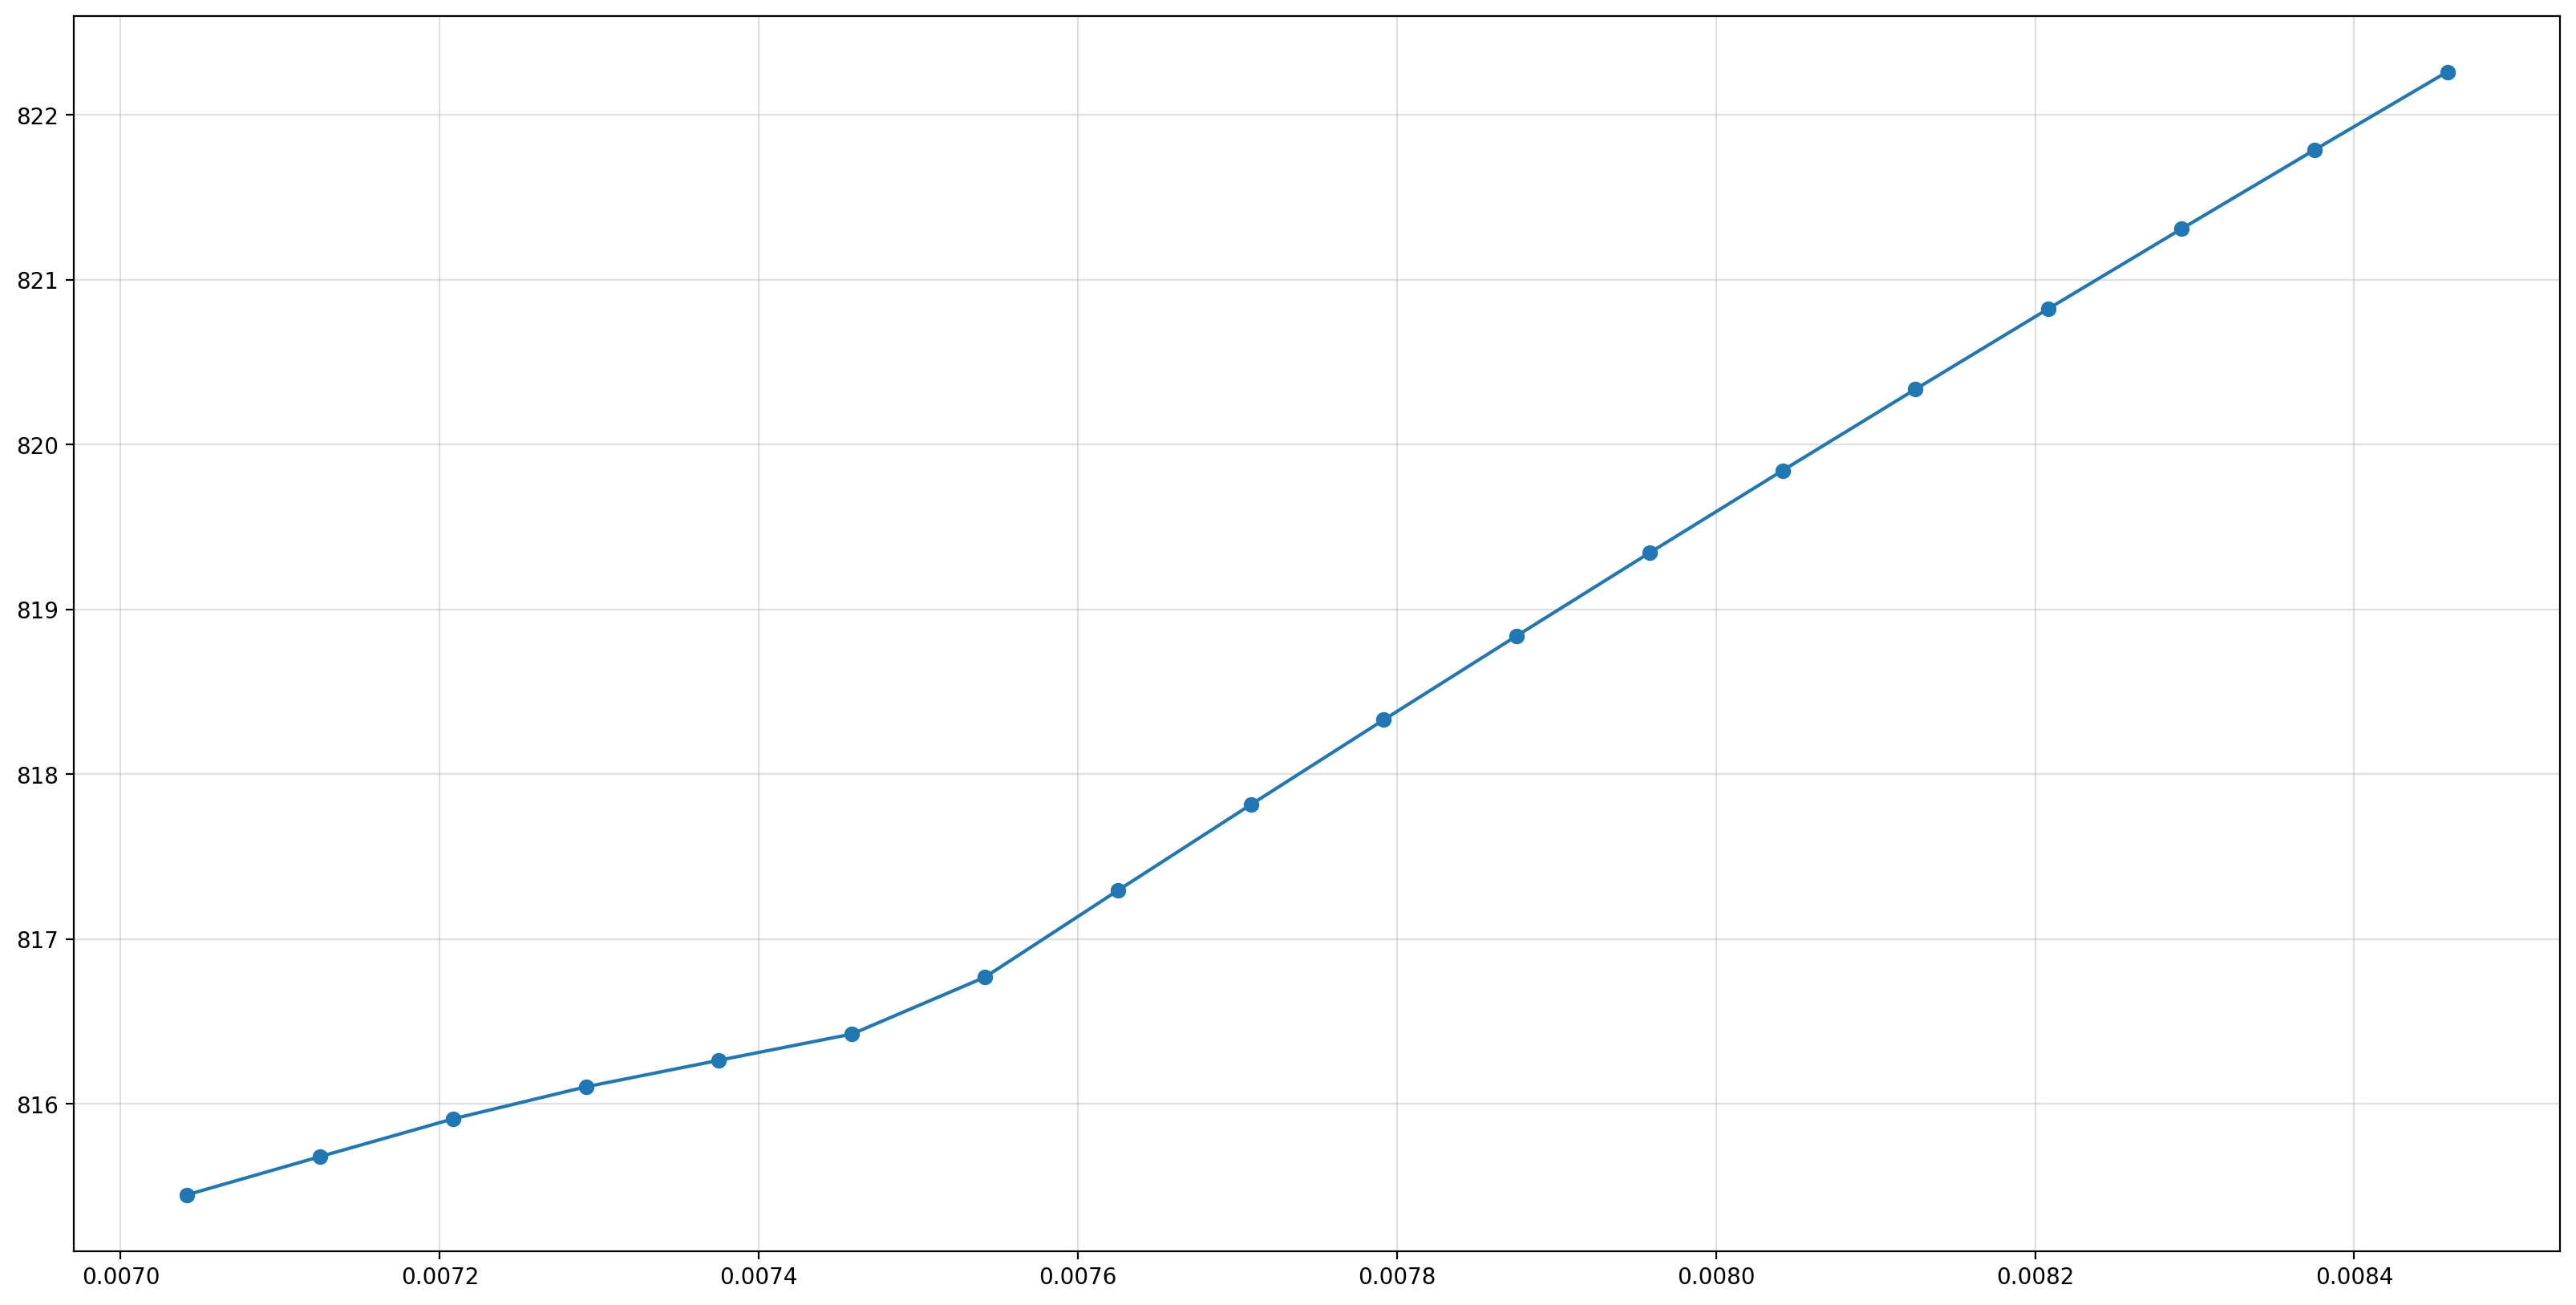

In [5]:
T_solid, u_v, T_v = solver.solutions[0]
z = heatpipe.solid.Z
r = heatpipe.solid.R

plt.figure(figsize=(20,10))
plt.plot(r, T_solid[0, :], "o-")
plt.grid(alpha=0.4)
plt.show()